In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from package.RankAMIP.logistic import run_logistic_regression
from package.RankAMIP.data_script import make_BT_design_matrix
from package.RankAMIP.logistic import LogisticAMIP
from package.RankAMIP.logistic import find_closest_matchups
from package.RankAMIP.logistic import isRankingRobust
from package.RankAMIP.data_script import *

### How Robust is the Search Arena to Data-Dropping?
https://huggingface.co/datasets/lmarena-ai/search-arena-24k

Search Arena is a crowdsourced in-the-wild evaluation platform for search-augmented LLM systems based on human preference. Unlike LM-Arena or SimpleQA, our data focuses on current events and diverse real-world use cases (https://huggingface.co/datasets/lmarena-ai/search-arena-24k).

### Load Data

In [ ]:
# Import datasets from 
# https://huggingface.co/datasets/lmsys/mt_bench_human_judgments
from datasets import load_dataset
ds = load_dataset("lmarena-ai/search-arena-24k")

/Users/JennyH/Library/Python/3.8/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# inspect the available splits
print(ds)  
test = ds["test"]

DatasetDict({
    test: Dataset({
        features: ['model_a', 'model_b', 'winner', 'judge', 'turn', 'timestamp', 'messages_a', 'messages_b', 'system_a_metadata', 'system_b_metadata', 'primary_intent', 'secondary_intent', 'languages'],
        num_rows: 24069
    })
})


In [4]:
df = test.to_pandas()
df.shape

(24069, 13)

In [5]:
# create a column winner_model_a, which is 1 if model_a is preferred, 0 if model_b is preferred
df['winner_model_a'] = df['winner'].apply(lambda x: 1 if x == 'model_a' else 0)
# create a column called winner_tie that is 1 if the winner is 'tie', else 0
df['winner_tie'] = df['winner'].apply(lambda x: 1 if x == 'tie' else 0)
df['winner_model_b'] = df['winner'].apply(lambda x: 1 if x == 'model_b' else 0)
df.head()

,model_a,model_b,winner,judge,turn,timestamp,messages_a,messages_b,system_a_metadata,system_b_metadata,primary_intent,secondary_intent,languages,winner_model_a,winner_tie,winner_model_b
0,sonar,sonar-reasoning,tie,78996144fc08f820066fdaa66f170da6e158c24ad70c4e...,1,2025-03-18 16:39:00.550,"[{'content': 'what models are you?', 'role': '...","[{'content': 'what models are you?', 'role': '...","{'citation_format_standardized': 'original', '...","{'citation_format_standardized': 'original', '...",Other,Unassigned,[English],0,1,0
1,gpt-4o-mini-search-preview,sonar-pro,model_a,023f8e28f2b51ef62a7adb0fdf06709b8004773b41ca38...,1,2025-03-18 16:39:35.849,[{'content': 'تجم تفسرلي علاش فما صبع زايد في ...,[{'content': 'تجم تفسرلي علاش فما صبع زايد في ...,"{'citation_format_standardized': 'original', '...","{'citation_format_standardized': 'original', '...",Explanation,Unassigned,[Arabic],1,0,0
2,sonar-reasoning,sonar-pro,model_b,febd105f4f29cf47f72d9b5bf825bdb848fb009b7b0cd6...,1,2025-03-18 16:43:18.951,[{'content': 'Ellen White über die Flache Erde...,[{'content': 'Ellen White über die Flache Erde...,"{'citation_format_standardized': 'original', '...","{'citation_format_standardized': 'original', '...",Info Synthesis,Factual Lookup,[German],0,0,1
3,gpt-4o-search-preview,sonar-pro,tie,d3560a0fe5416204140c8b1269b3ff10108c36fe59d355...,1,2025-03-18 16:43:47.861,"[{'content': 'Test', 'role': 'user'}, {'conten...","[{'content': 'Test', 'role': 'user'}, {'conten...","{'citation_format_standardized': 'original', '...","{'citation_format_standardized': 'original', '...",Other,Unassigned,[English],0,1,0
4,gpt-4o-mini-search-preview,sonar-pro,model_b,febd105f4f29cf47f72d9b5bf825bdb848fb009b7b0cd6...,1,2025-03-18 16:47:47.787,"[{'content': 'Site: ""m.egwwritings.org/en"" übe...","[{'content': 'Site: ""m.egwwritings.org/en"" übe...","{'citation_format_standardized': 'original', '...","{'citation_format_standardized': 'original', '...",Info Synthesis,Unassigned,"[German, English]",0,0,1


In [6]:
ties = df[df['winner_tie'] == 1]
print(f"Number of ties: {len(ties)}")
# proportion of ties.
print(f"Proportion of ties: {len(ties) / len(df):.2%}")
# note, the proportion of ties is 9.17% for the LLM-as-judge data and 23.25% for the human-as-judge data.

Number of ties: 2502
Proportion of ties: 10.40%


In [21]:
rawBT = df[['model_a', 'model_b', 'winner_model_a', 'winner_tie']]
rawBT.head()
rawBT.shape
# rawBT_noTies.head() # (2575, 3)
# rawBT_noTies.shape

(24069, 4)

In [22]:
# how to get the unique names in both columns
model_a_names = df['model_a'].unique()
model_b_names = df['model_b'].unique()
# combine the two arrays and get the unique names
model_names = np.unique(np.concatenate((model_a_names, model_b_names)))
# print the number of unique model names
print(f"Number of unique model names: {len(model_names)}")

Number of unique model names: 13


In [19]:
for model in model_names:
    filtered = df[
        (df['model_a'] == model) | 
        (df['model_b'] == model)
    ]
    print(f"{model}: {filtered.shape[0]}")

gemini-2.0-flash-grounding: 3603
gemini-2.5-flash-preview-04-17-grounding: 2300
gemini-2.5-pro-exp-03-25-grounding: 4044
gemini-2.5-pro-exp-03-25-wo-search: 922
gpt-4o-mini-search-preview: 2866
gpt-4o-search-preview: 4169
gpt-4o-search-preview-high: 4132
gpt-4o-search-preview-high-loc: 4811
sonar: 3293
sonar-pro: 2878
sonar-pro-high: 4786
sonar-reasoning: 4387
sonar-reasoning-pro-high: 4662


In [23]:
# make the BT design matrix.
X, y, player_to_id = make_BT_design_matrix(rawBT, weight_tie = True)
X.shape, y.shape

((48138, 12), (48138,))

### Uniform Data-dropping

In [24]:
# compute BT scores.
model_full = run_logistic_regression(X, y)

# prepend model 0, the reference model, which has score 0.
bt_scores = np.insert(model_full.coef_[0], 0, 0)

# combine bt_scores with player names
id_to_player = {v: k for k, v in player_to_id.items()}
bt_scores_with_names = {id_to_player[i]: score for i, score in enumerate(bt_scores)}

# Determine the original top model
top_model_original = max(bt_scores_with_names.items(), key=lambda x: x[1])[0]
print("original top 5 models: ", dict(sorted(bt_scores_with_names.items(), key=lambda x: x[1], reverse=True)[:5]))

num_trials = 100
num_agree = 0

for trial in range(num_trials):
    indices = np.random.choice(X.shape[0], size=int(X.shape[0]*0.01), replace=False)
    X_dropped = np.delete(X, indices, axis=0)
    y_dropped = np.delete(y, indices, axis=0)

    model_dropped = run_logistic_regression(X_dropped, y_dropped)
    bt_scores_dropped = np.insert(model_dropped.coef_[0], 0, 0)
    bt_scores_with_names_dropped = {id_to_player[i]: score for i, score in enumerate(bt_scores_dropped)}
    top_model_dropped = max(bt_scores_with_names_dropped.items(), key=lambda x: x[1])[0]
    if top_model_dropped == top_model_original:
        num_agree += 1

    # Optional: Show some progress every 10 iterations
    if (trial+1) % 10 == 0:
        print(f"Completed {trial+1} trials...")

print(f"Fraction of times top-ranked model stays the same after dropping 1% of the data: {num_agree/num_trials:.2f}")

original top 5 models:  {'sonar-reasoning-pro-high': 0.5775739445327741, 'gemini-2.5-pro-exp-03-25-grounding': 0.5256163078266437, 'sonar-pro-high': 0.4780486063881087, 'sonar-reasoning': 0.38504489003194325, 'gemini-2.5-flash-preview-04-17-grounding': 0.3689351989947345}
Completed 10 trials...
Completed 20 trials...
Completed 30 trials...
Completed 40 trials...
Completed 50 trials...
Completed 60 trials...
Completed 70 trials...
Completed 80 trials...
Completed 90 trials...
Completed 100 trials...
Fraction of times top-ranked model stays the same after dropping 1% of the data: 1.00


### Bootstrap Confidence Intervals

In [14]:
import importlib
import compute_CIs
importlib.reload(compute_CIs)

<module 'compute_CIs' from '/Users/JennyH/Desktop/IsRankingRobust/compute_CIs.py'>

In [15]:
BOOTSTRAP_ROUNDS = 100
### Obtain Bootstrap Confidence Intervals.
np.random.seed(42)
bootstrap_elo_lu = compute_CIs.get_bootstrap_result(df, compute_CIs.compute_mle_elo, BOOTSTRAP_ROUNDS)

bootstrap: 100%|██████████| 100/100 [00:03<00:00, 27.95it/s]


In [16]:
bootstrap_elo_lu.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_elo_lu.quantile(0.025)
ci_upper = bootstrap_elo_lu.quantile(0.975)
ci_med = bootstrap_elo_lu.median()
ci_df = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper
})
ci_df

,2.5%,Median,97.5%
model_a,,,
sonar-reasoning-pro-high,1072.548279,1082.777103,1091.461216
gemini-2.5-pro-exp-03-25-grounding,1074.057202,1081.588609,1091.607236
sonar-pro-high,1051.365883,1062.023452,1070.701142
sonar-reasoning,1035.349110,1045.186894,1056.662838
sonar-pro,1016.534203,1031.305528,1042.236865
sonar,1016.714448,1027.469801,1041.801880
gemini-2.5-flash-preview-04-17-grounding,987.834559,1004.662526,1022.993955
gemini-2.5-pro-exp-03-25-wo-search,967.797199,991.248790,1015.576649
gemini-2.0-flash-grounding,953.330823,966.694862,981.059153


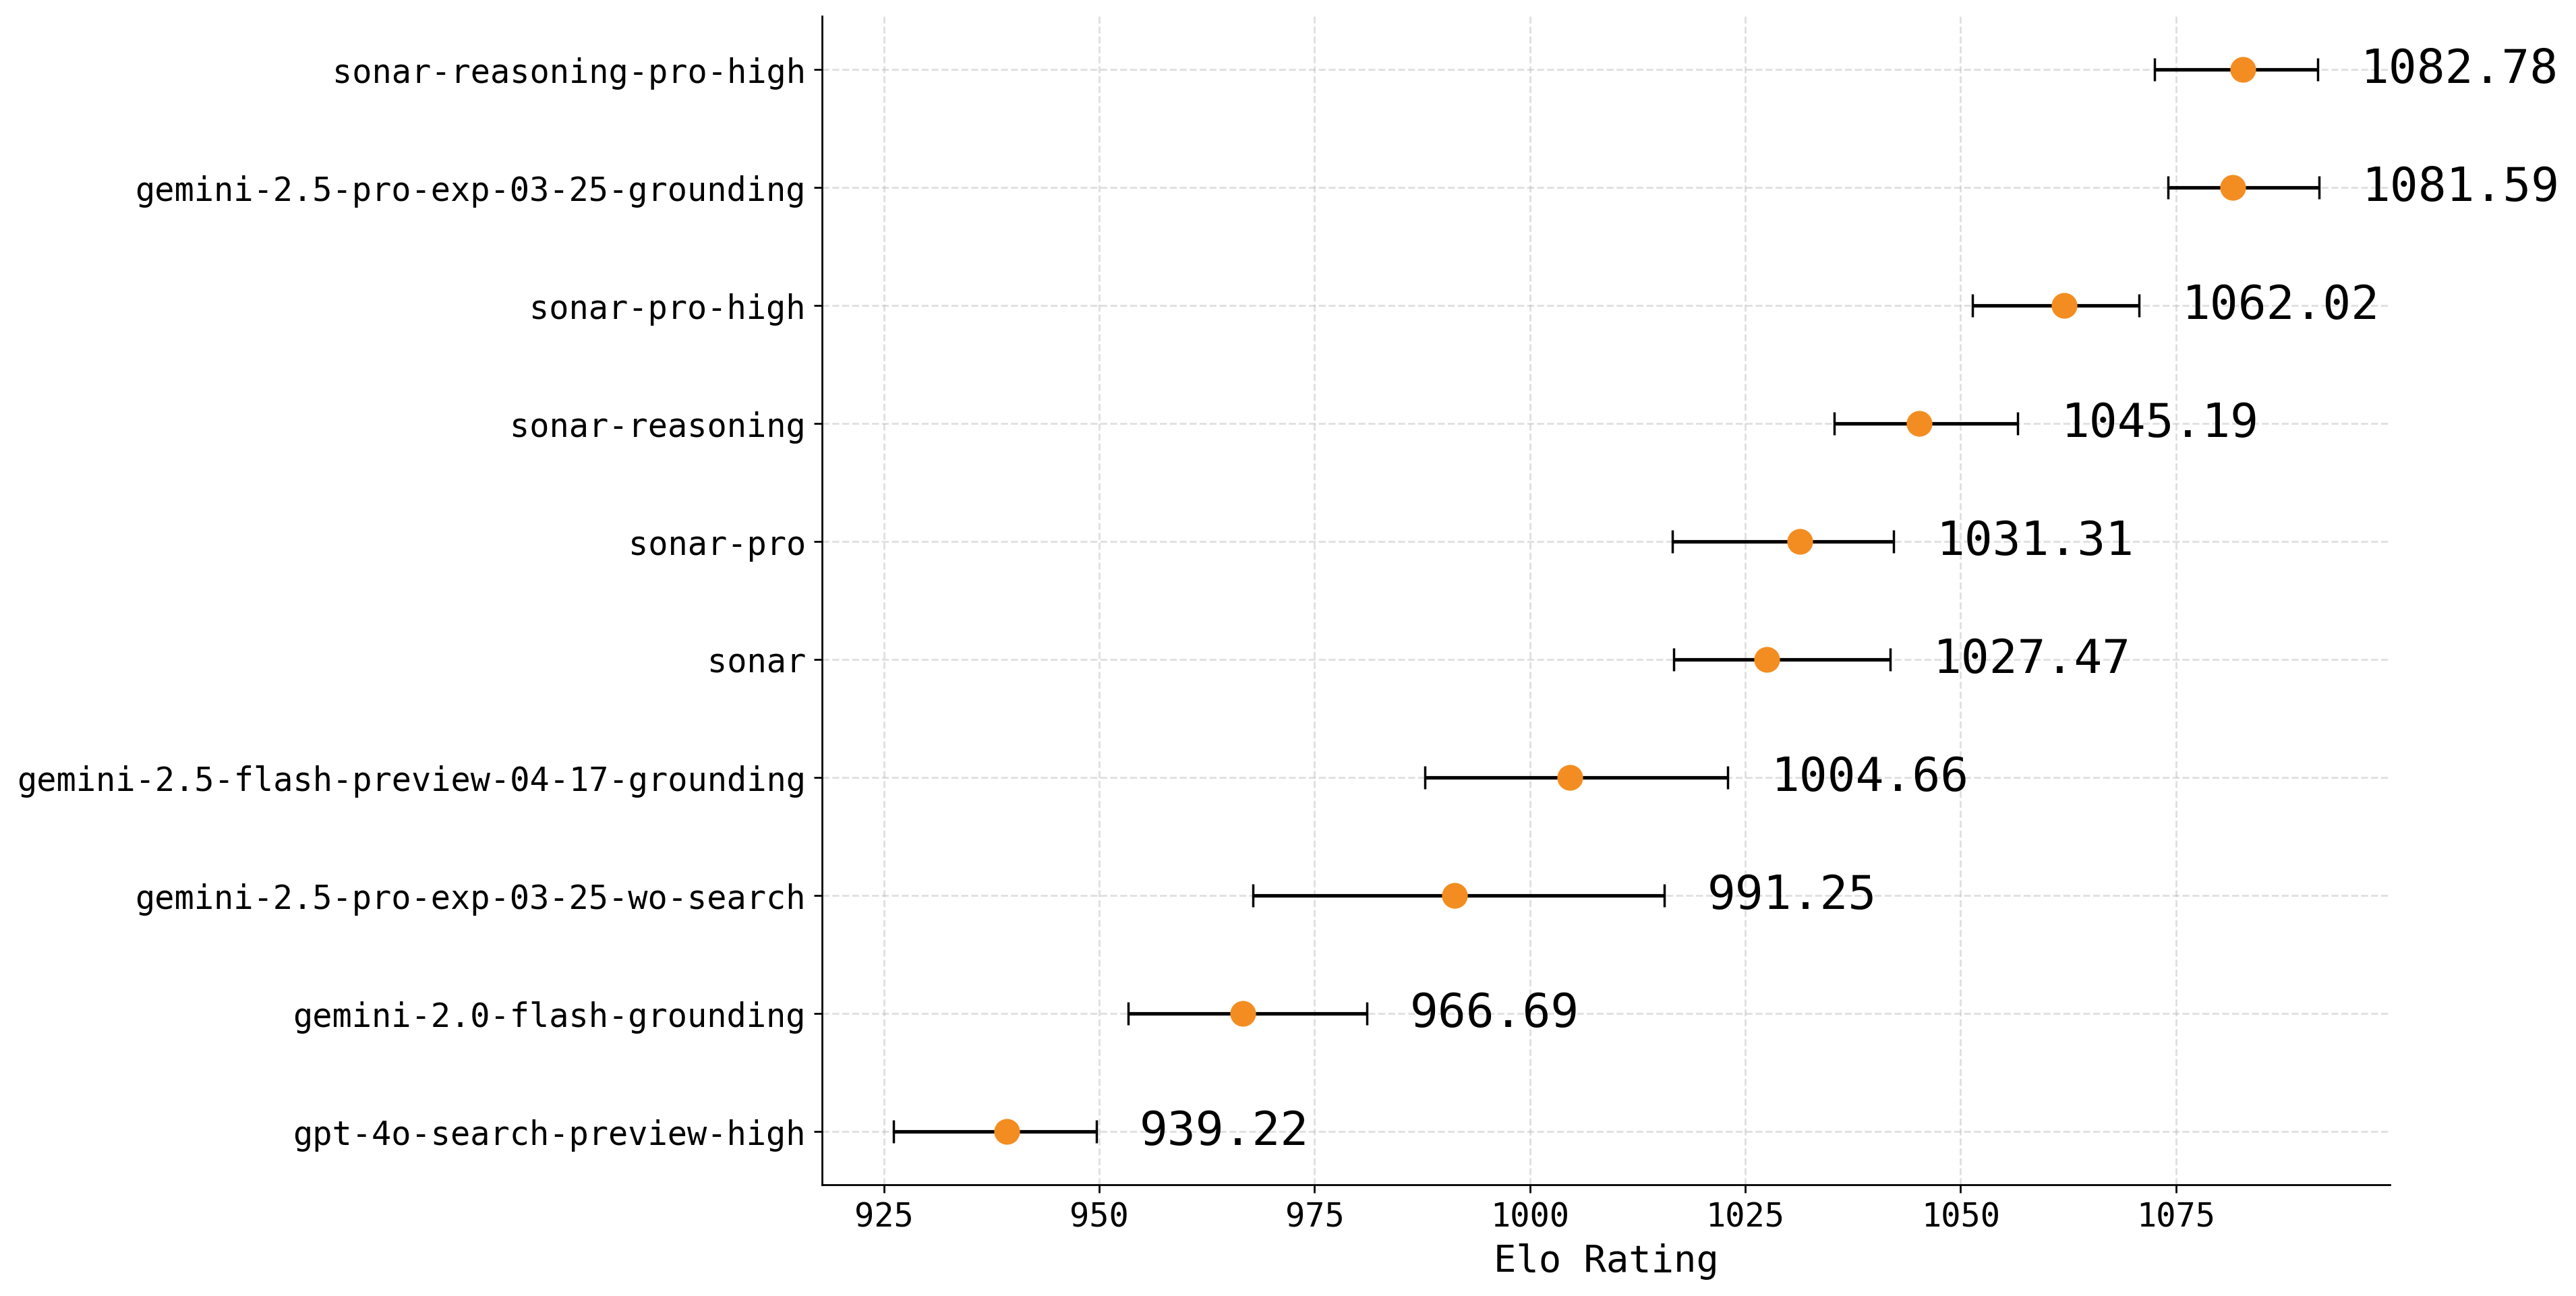

In [17]:
# plot only the top 10 models.
compute_CIs.plot_elo_confidence_intervals(ci_df.head(10))

481


bootstrap: 100%|██████████| 100/100 [00:03<00:00, 31.15it/s]


                                           2.5%       Median        97.5%
model_a                                                                  
sonar-reasoning-pro-high            1070.302826  1082.743655  1095.963544
gemini-2.5-pro-exp-03-25-grounding  1067.841579  1079.600828  1091.136457
sonar-pro-high                      1051.167056  1062.137457  1070.968980
sonar-reasoning                     1033.603079  1045.047912  1054.798203
sonar-pro                           1020.345028  1030.703846  1043.880699
fraction of preferences dropped: 0.00103868046034318


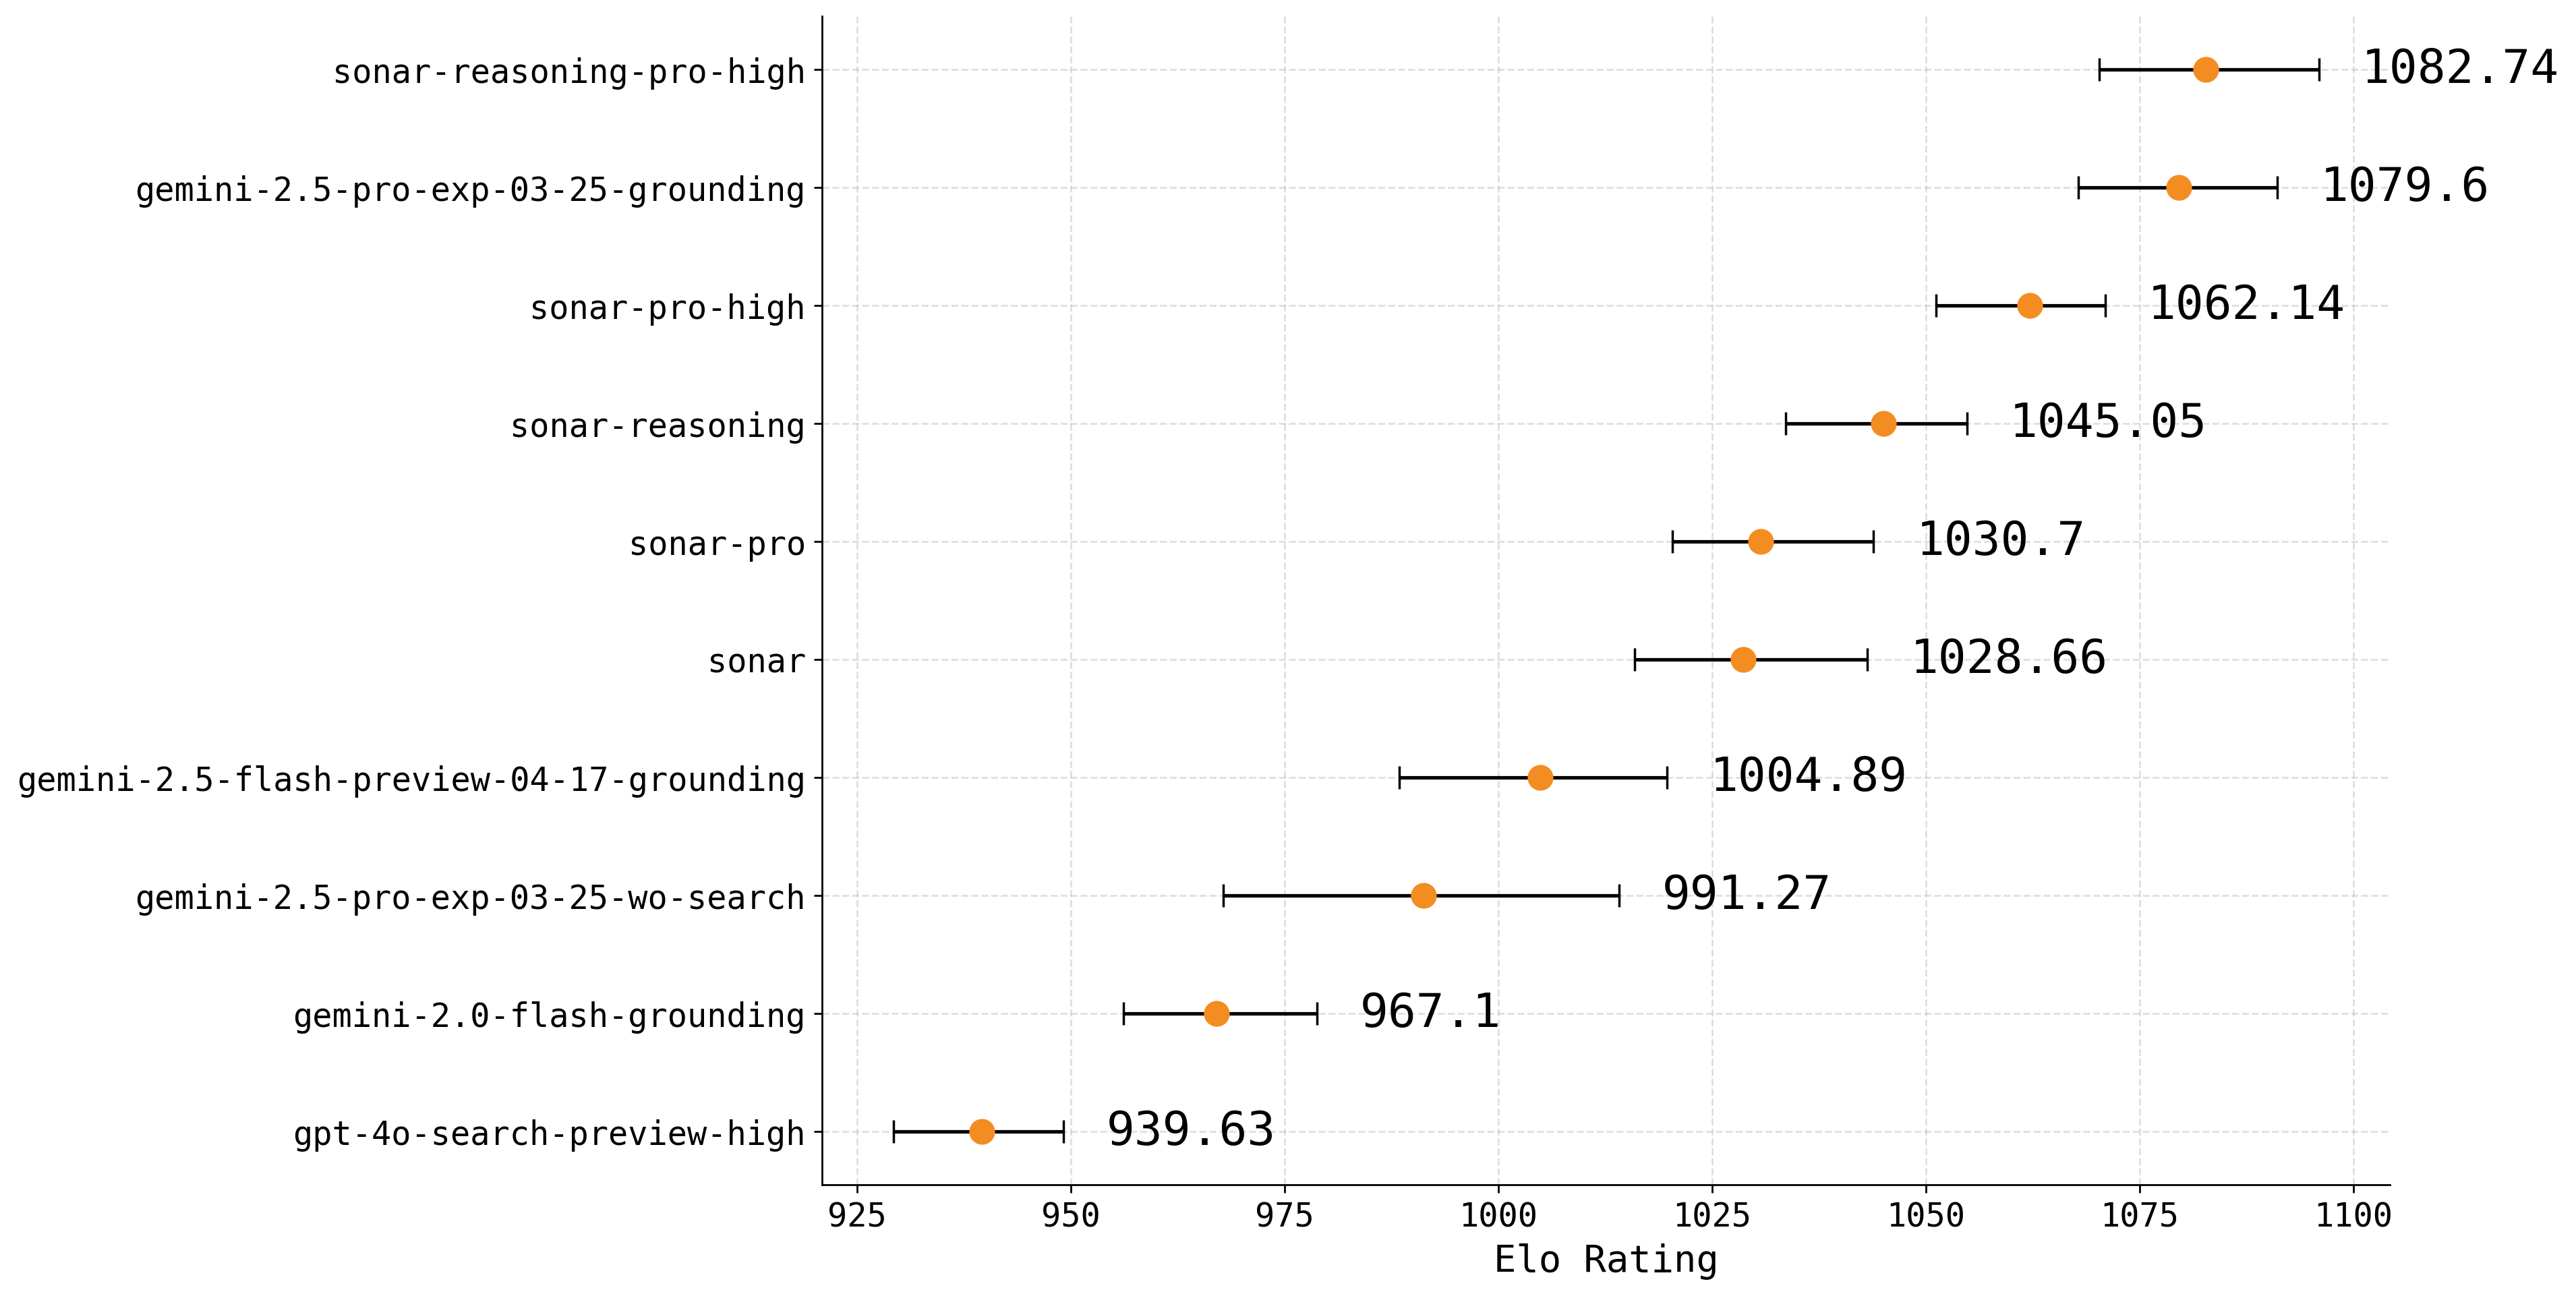

Number of unique model names: 13
Number of ties: 2502
Proportion of ties: 10.40%
original top 5 models:  {'sonar-reasoning-pro-high': 0.5775739445327741, 'gemini-2.5-pro-exp-03-25-grounding': 0.5256163078266437, 'sonar-pro-high': 0.4780486063881087, 'sonar-reasoning': 0.38504489003194325, 'gemini-2.5-flash-preview-04-17-grounding': 0.3689351989947345}
Completed 10 trials...
Completed 20 trials...
Completed 30 trials...
Completed 40 trials...
Completed 50 trials...
Completed 60 trials...
Completed 70 trials...
Completed 80 trials...
Completed 90 trials...
Completed 100 trials...
Fraction of times top-ranked model stays the same after dropping 1% of the data: 1.00


In [ ]:
#### Identify the pool of influential points for auditing Top-1 Robustness
import math
k = 2
alphaN = math.floor(0.02 * len(df))
print(alphaN)
chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, top1_mis_indices = isRankingRobust(k, alphaN, X, y,  weighted = True)

# remove top_1_mis from df
num_dropped = 25
df_dropped = df.drop(top1_mis_indices[:num_dropped]).reset_index(drop=True)

len(df), len(df_dropped)

BOOTSTRAP_ROUNDS = 100
bootstrap_top1_mis_dropped = compute_CIs.get_bootstrap_result(df_dropped, compute_CIs.compute_mle_elo, BOOTSTRAP_ROUNDS)

bootstrap_top1_mis_dropped.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_top1_mis_dropped.quantile(0.025)
ci_upper = bootstrap_top1_mis_dropped.quantile(0.975)
ci_med = bootstrap_top1_mis_dropped.median()
ci_df_dropped = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper,
})
print(ci_df_dropped.head())

print(f'fraction of preferences dropped: {num_dropped / len(df)}')
compute_CIs.plot_elo_confidence_intervals(ci_df_dropped.head(10), title=f"Top 10 Elo Ratings Upon Removing {num_dropped} out of {len(df)} of Preferences")

# the unique model names
model_a_names = df['model_a'].unique()
model_b_names = df['model_b'].unique()
model_names = np.unique(np.concatenate((model_a_names, model_b_names)))

print(f"Number of unique model names: {len(model_names)}")
ties = df[df['winner_tie'] == 1]
print(f"Number of ties: {len(ties)}")
# proportion of ties.
print(f"Proportion of ties: {len(ties) / len(df):.2%}")
#### Keep ties.
# drop rows in df with df['winner_tie'] == 1
rawBT = df[['model_a', 'model_b', 'winner_model_a', 'winner_tie']]
rawBT.head()
# make weighted design matrix for BT.
X, y, player_to_id = make_BT_design_matrix(rawBT, weight_tie = True)
X.shape, y.shape
## Uniform Data-dropping
# compute BT scores.
model_full = run_logistic_regression(X, y)

# prepend model 0, the reference model, which has score 0.
bt_scores = np.insert(model_full.coef_[0], 0, 0)

# combine bt_scores with player names
id_to_player = {v: k for k, v in player_to_id.items()}
bt_scores_with_names = {id_to_player[i]: score for i, score in enumerate(bt_scores)}

# Determine the original top model
top_model_original = max(bt_scores_with_names.items(), key=lambda x: x[1])[0]
print("original top 5 models: ", dict(sorted(bt_scores_with_names.items(), key=lambda x: x[1], reverse=True)[:5]))

num_trials = 100
num_agree = 0

for trial in range(num_trials):
    indices = np.random.choice(X.shape[0], size=int(X.shape[0]*0.01), replace=False)
    X_dropped = np.delete(X, indices, axis=0)
    y_dropped = np.delete(y, indices, axis=0)

    model_dropped = run_logistic_regression(X_dropped, y_dropped)
    bt_scores_dropped = np.insert(model_dropped.coef_[0], 0, 0)
    bt_scores_with_names_dropped = {id_to_player[i]: score for i, score in enumerate(bt_scores_dropped)}
    top_model_dropped = max(bt_scores_with_names_dropped.items(), key=lambda x: x[1])[0]
    if top_model_dropped == top_model_original:
        num_agree += 1

    # Optional: Show some progress every 10 iterations
    if (trial+1) % 10 == 0:
        print(f"Completed {trial+1} trials...")

print(f"Fraction of times top-ranked model stays the same after dropping 1% of the data: {num_agree/num_trials:.2f}")

#### Run Top-k Robustness Check.

In [ ]:
ks = [1]
results = {}
for k in ks:
    alphaN = 1
    chatbotA = -1
    while chatbotA == -1:
        chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, chatIndices = isRankingRobust(k, alphaN, X, y, weighted = True)
        results[(k, alphaN)] = (chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, chatIndices)
        alphaN += 1
        print(alphaN)

In [ ]:
# find the (k, alpha N) pairs that are non-robust.
results_nonrobust = {k: v for k, v in results.items() if v[0] != -1}
results_nonrobust

{(1, 61): (9,
  8,
  0.051957636706130406,
  -8.164843926616872e-05,
  array([22164, 12847, 12819, 21810, 11852, 19956,  9492, 15447, 11324,
         16583, 12733, 10116, 21940, 15552,  9451, 12602, 21977, 11499,
         12576, 10146, 12557, 11519, 15699,  9420, 12851, 18068, 12931,
         11278, 13279, 11143, 11163, 21587,  9963, 13226,  9586, 20632,
         13191,  9978, 13189, 12456, 11204, 17160, 13129, 18238, 18231,
         10009, 13112, 15234, 11251, 20575, 13043, 10030, 11209,  9607,
         20336, 15733, 22646, 12061, 11768, 12023, 10375])),
 (3, 72): (5,
  10,
  0.19372304361568282,
  -0.0017888236439169702,
  array([21206, 17825, 19552, 20305, 21019, 16951, 18279, 19763, 19295,
         17846, 18468, 18236, 19441, 16623, 21028, 19084, 19674, 19374,
         21021, 16821, 20784, 18565, 20226, 20717, 18984, 18224, 16463,
         20930, 16563, 17610, 19121, 20967, 20897, 17482, 18785, 18726,
         18717, 20580, 18865, 20110, 16362, 18870, 21049, 21046, 19628,
         

In [ ]:
# save results as a .pkl file.
# import pickle
# with open('results/SearchArenaNonrobustWtd.pkl', 'wb') as f:
#     pickle.dump(results_nonrobust, f)

In [ ]:
from package.RankAMIP.plot_util import *
rankings = return_rankings_list(X, y, results, 1, 61, player_to_id)

In [ ]:
# plot the rankings on the original arena
filename_to_save = 'fig/top_search_arena.png'
plot_title = 'Model Rankings in Search Arena'
plot_bt_scores(X, y, rankings, alphaN, 13, plot_title, filename_to_save)

In [ ]:
### Load in results.
import pickle

with open("results/SearchArenaNonrobustWtd.pkl", "rb") as f:
    SearchArenaDataDropped = pickle.load(f)

In [ ]:
SearchArenaDataDropped

{(1, 61): (9,
  8,
  0.051957636706130406,
  -8.164843926616872e-05,
  array([22164, 12847, 12819, 21810, 11852, 19956,  9492, 15447, 11324,
         16583, 12733, 10116, 21940, 15552,  9451, 12602, 21977, 11499,
         12576, 10146, 12557, 11519, 15699,  9420, 12851, 18068, 12931,
         11278, 13279, 11143, 11163, 21587,  9963, 13226,  9586, 20632,
         13191,  9978, 13189, 12456, 11204, 17160, 13129, 18238, 18231,
         10009, 13112, 15234, 11251, 20575, 13043, 10030, 11209,  9607,
         20336, 15733, 22646, 12061, 11768, 12023, 10375])),
 (3, 72): (5,
  10,
  0.19372304361568282,
  -0.0017888236439169702,
  array([21206, 17825, 19552, 20305, 21019, 16951, 18279, 19763, 19295,
         17846, 18468, 18236, 19441, 16623, 21028, 19084, 19674, 19374,
         21021, 16821, 20784, 18565, 20226, 20717, 18984, 18224, 16463,
         20930, 16563, 17610, 19121, 20967, 20897, 17482, 18785, 18726,
         18717, 20580, 18865, 20110, 16362, 18870, 21049, 21046, 19628,
         

In [ ]:
player_to_id

{'sonar': 0,
 'gpt-4o-mini-search-preview': 1,
 'sonar-reasoning': 2,
 'gpt-4o-search-preview': 3,
 'sonar-pro': 4,
 'gpt-4o-search-preview-high': 5,
 'sonar-pro-high': 6,
 'gpt-4o-search-preview-high-loc': 7,
 'gemini-2.0-flash-grounding': 8,
 'gemini-2.5-pro-exp-03-25-grounding': 9,
 'sonar-reasoning-pro-high': 10,
 'gemini-2.5-pro-exp-03-25-wo-search': 11,
 'gemini-2.5-flash-preview-04-17-grounding': 12}

In [ ]:
# find the two models that changed ranking.
## Count number of games between the first- and second-place models played in total.
is_sonar_gemini = (
    (df['model_a'].str.contains('sonar-reasoning-pro-high') & df['model_b'].str.contains('gemini-2.5-pro-exp-03-25-grounding')) |
    (df['model_a'].str.contains('gemini-2.5-pro-exp-03-25-grounding') & df['model_b'].str.contains('sonar-reasoning-pro-high'))
)

num_sonar_gemini = df[is_sonar_gemini].shape[0]
print("Number of games between 'sonar-reasoning-pro-high' and 'gemini-2.5-pro-exp-03-25-grounding': ", num_sonar_gemini)

Number of games between 'sonar-reasoning-pro-high' and 'gemini-2.5-pro-exp-03-25-grounding':  524


In [ ]:
# model pairs
df['model_pair'] = df.apply(lambda row: tuple(sorted([row['model_a'], row['model_b']])), axis=1)
df['model_pair']

# Compute average games per model pair across the arena.
pair_counts = df['model_pair'].value_counts()
average_games_per_pair = pair_counts.mean()
print("Average number of games per model pair:", average_games_per_pair)

Average number of games per model pair: 267.43333333333334


In [ ]:
# that is, find all games that are between the two models.
dfFlippedRanking = df[is_sonar_gemini]
# find the win margin
## Count number of games between the two that 'gpt-4' won.
sonar_wins = (
    ((dfFlippedRanking['model_a']=='sonar-reasoning-pro-high') & (dfFlippedRanking['winner'] == 'model_a')) |
    ((dfFlippedRanking['model_b']=='sonar-reasoning-pro-high') & (dfFlippedRanking['winner'] == 'model_b'))
)
gemini_wins = ( 
    ((dfFlippedRanking['model_a']=='gemini-2.5-pro-exp-03-25-grounding') & (dfFlippedRanking['winner'] == 'model_a')) |
    ((dfFlippedRanking['model_b']=='gemini-2.5-pro-exp-03-25-grounding') & (dfFlippedRanking['winner'] == 'model_b'))
)
num_sonar_wins = dfFlippedRanking[sonar_wins].shape[0]
num_gemini_wins = dfFlippedRanking[gemini_wins].shape[0]
print("Proportion of games that Sonar won: ", num_sonar_wins / (num_sonar_wins + num_gemini_wins))
print("Proportion of games that Gemini won: ", num_gemini_wins / (num_sonar_wins + num_gemini_wins))


Proportion of games that Sonar won:  0.478494623655914
Proportion of games that Gemini won:  0.521505376344086
